# 1. Install Dependencies

In [ ]:
# Install required libraries
!pip install -q torch torchvision torchaudio opencv-python scikit-image networkx python-louvain tqdm

import os
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import networkx as nx
from community import community_louvain  # Corrected import for python-louvain
from torch.utils.data import Dataset, DataLoader, Subset, random_split
from skimage.metrics import structural_similarity as ssim
from tqdm import tqdm
import math

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
device

device(type='cuda')

# Kaggle Datase

In [ ]:
DATASET_PATH = "/content"

In [ ]:
import zipfile
import os

zip_path = f"/content/kvasir-seg.zip"

extract_path = DATASET_PATH

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# 3. Configuration & Dataset

In [ ]:
class Config:
    DATASET_PATH = "/content/Kvasir-SEG" # Ensure this path exists after unzipping
    IMAGE_SIZE = 128
    BATCH_SIZE = 8
    EPOCHS = 10
    LR = 1e-4
    PRUNE_RATIO = 0.5  # Keep 50% of the data
    TOP_K_PERCENT = 0.1 # Graph connectivity
    SEED = 42

class PolypDataset(Dataset):
    def __init__(self, img_dir, mask_dir, img_names):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.img_names = img_names

    def __len__(self):
        return len(self.img_names)

    def __getitem__(self, idx):
        name = self.img_names[idx]

        # Load and resize image
        img = cv2.imread(os.path.join(self.img_dir, name))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (Config.IMAGE_SIZE, Config.IMAGE_SIZE))
        img = torch.tensor(img).permute(2,0,1).float() / 255.0

        # Load and resize mask
        mask = cv2.imread(os.path.join(self.mask_dir, name), 0)
        mask = cv2.resize(mask, (Config.IMAGE_SIZE, Config.IMAGE_SIZE))
        mask = (mask > 127).astype(np.float32)
        mask = torch.tensor(mask).unsqueeze(0)

        return img, mask

# 3. Similarity & Graph Construction

In [ ]:
def get_similarity_matrix(dataset):
    """Computes SSIM between all pairs. O(n^2) complexity."""
    n = len(dataset)
    images = []
    print("Pre-loading images for similarity computation...")
    for i in range(n):
        img, _ = dataset[i]
        # Convert to grayscale numpy for SSIM
        gray = torch.mean(img, dim=0).numpy()
        images.append(gray)

    adj_matrix = np.zeros((n, n))
    print("Building Similarity Matrix...")
    for i in tqdm(range(n)):
        for j in range(i + 1, n):
            score = ssim(images[i], images[j], data_range=1.0)
            adj_matrix[i, j] = score
            adj_matrix[j, i] = score
    return adj_matrix

def build_pruned_graph(adj_matrix, top_k_percent=0.1):
    """Converts similarity matrix to a Sparse Graph using Top-K neighbors."""
    G = nx.Graph()
    n = adj_matrix.shape[0]
    k = max(1, int(n * top_k_percent))

    for i in range(n):
        # Get indices of top k similar images
        neighbors = np.argsort(adj_matrix[i])[-k:]
        for nj in neighbors:
            if i != nj:
                G.add_edge(i, nj, weight=adj_matrix[i, nj])
    return G

# 4. Community-Based Pruning (The Core Logic)

In [ ]:
def prune_dataset_prime(G, prune_ratio=0.5):
    """
    PRIME Strategy:
    1. Detect communities using the Louvain method.
    2. Within each community, rank nodes by degree (importance).
    3. Select top performers to represent the manifold.
    """
    # Use the explicit community_louvain call to avoid AttributeError
    partition = community_louvain.best_partition(G)

    communities = {}
    for node, comm_id in partition.items():
        communities.setdefault(comm_id, []).append(node)

    selected_indices = []

    # Representative Selection (Paper Eq. Mapping: Node Centrality within Cluster)
    for comm_id, nodes in communities.items():
        # Sort nodes by degree: images with most 'similar' neighbors are prioritized
        nodes_sorted = sorted(nodes, key=lambda n: G.degree(n), reverse=True)

        # Determine sampling quota for this specific community
        num_to_keep = max(1, math.ceil(len(nodes) * prune_ratio))
        selected_indices.extend(nodes_sorted[:num_to_keep])

    return selected_indices

# 5. Model and Training Utilities

In [ ]:
class UNetLite(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = self.conv_block(3, 32)
        self.enc2 = self.conv_block(32, 64)
        self.pool = nn.MaxPool2d(2)
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dec = self.conv_block(64, 32)
        self.final = nn.Conv2d(32, 1, 1)

    def conv_block(self, in_c, out_c):
        return nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        c1 = self.enc1(x)
        x = self.pool(c1)
        x = self.enc2(x)
        x = self.up(x)
        x = self.dec(x)
        return torch.sigmoid(self.final(x))

def dice_loss(pred, target):
    smooth = 1e-6
    iflat = pred.view(-1)
    tflat = target.view(-1)
    intersection = (iflat * tflat).sum()
    return 1 - ((2. * intersection + smooth) / (iflat.sum() + tflat.sum() + smooth))

def train_model(train_loader, epochs=5):
    model = UNetLite().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=Config.LR)

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for imgs, masks in train_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            optimizer.zero_grad()
            preds = model(imgs)
            loss = F.binary_cross_entropy(preds, masks) + dice_loss(preds, masks)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}")
    return model

# Execution Pipeline (The Fix)

In [ ]:
# 1. Prepare Paths
IMG_DIR = f"{Config.DATASET_PATH}/images"
MASK_DIR = f"{Config.DATASET_PATH}/masks"
all_names = sorted(os.listdir(IMG_DIR))[:400] # Increased limit slightly

# 2. Split into Train and Test (CRITICAL FIX)
split_idx = int(0.8 * len(all_names))
train_names = all_names[:split_idx]
test_names = all_names[split_idx:]

full_train_ds = PolypDataset(IMG_DIR, MASK_DIR, train_names)
test_ds = PolypDataset(IMG_DIR, MASK_DIR, test_names)

# 3. Compute Pruning on the Train Set only
adj = get_similarity_matrix(full_train_ds)
G = build_pruned_graph(adj, top_k_percent=Config.TOP_K_PERCENT)
pruned_indices = prune_dataset_prime(G, prune_ratio=Config.PRUNE_RATIO)
pruned_train_ds = Subset(full_train_ds, pruned_indices)

print(f"Original Train Size: {len(full_train_ds)}")
print(f"Pruned Train Size: {len(pruned_train_ds)}")

# 4. Data Loaders
full_loader = DataLoader(full_train_ds, batch_size=Config.BATCH_SIZE, shuffle=True)
pruned_loader = DataLoader(pruned_train_ds, batch_size=Config.BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=Config.BATCH_SIZE, shuffle=False)

# 5. Train & Compare
print("\n--- Training Full Model ---")
model_full = train_model(full_loader, epochs=Config.EPOCHS)

print("\n--- Training Pruned Model ---")
model_pruned = train_model(pruned_loader, epochs=Config.EPOCHS)

Pre-loading images for similarity computation...
Building Similarity Matrix...


100%|██████████| 320/320 [01:00<00:00,  5.32it/s]


Original Train Size: 320
Pruned Train Size: 161

--- Training Full Model ---
Epoch 1/10, Loss: 1.3882
Epoch 2/10, Loss: 1.3054
Epoch 3/10, Loss: 1.2691
Epoch 4/10, Loss: 1.2418
Epoch 5/10, Loss: 1.2149
Epoch 6/10, Loss: 1.1975
Epoch 7/10, Loss: 1.1800
Epoch 8/10, Loss: 1.1622
Epoch 9/10, Loss: 1.1457
Epoch 10/10, Loss: 1.1284

--- Training Pruned Model ---
Epoch 1/10, Loss: 1.5122
Epoch 2/10, Loss: 1.4149
Epoch 3/10, Loss: 1.3717
Epoch 4/10, Loss: 1.3570
Epoch 5/10, Loss: 1.3176
Epoch 6/10, Loss: 1.2929
Epoch 7/10, Loss: 1.2826
Epoch 8/10, Loss: 1.2654
Epoch 9/10, Loss: 1.2657
Epoch 10/10, Loss: 1.2432


# Evaluation

In [ ]:
import time

def calculate_metrics(pred, target):
    """
    Computes metrics for a single batch.
    """
    smooth = 1e-6
    pred = (pred > 0.5).float()
    target = (target > 0.5).float()

    # Dice Score
    intersection = (pred * target).sum()
    dice = (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)

    # IoU (Intersection over Union)
    union = pred.sum() + target.sum() - intersection
    iou = (intersection + smooth) / (union + smooth)

    # Pixel Accuracy
    correct = (pred == target).float().sum()
    total = torch.numel(pred)
    accuracy = correct / total

    return dice.item(), iou.item(), accuracy.item()

def evaluate_and_time(model, loader):
    """
    Evaluates the model and calculates average metrics.
    """
    model.eval()
    dices, ious, accs = [], [], []

    start_time = time.time()
    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)
            preds = model(imgs)

            d, i, a = calculate_metrics(preds, masks)
            dices.append(d)
            ious.append(i)
            accs.append(a)

    end_time = time.time()

    metrics = {
        "Dice": np.mean(dices),
        "IoU": np.mean(ious),
        "Accuracy": np.mean(accs),
        "Inference_Time": end_time - start_time
    }
    return metrics

## 2. Comparative Training Script

In [ ]:
results = {}

# 1. Train & Time Full Model
print("Training Full Model...")
start_full = time.time()
model_full = train_model(full_loader, epochs=Config.EPOCHS)
time_full = time.time() - start_full

# 2. Train & Time Pruned Model
print("\nTraining Pruned Model...")
start_pruned = time.time()
model_pruned = train_model(pruned_loader, epochs=Config.EPOCHS)
time_pruned = time.time() - start_pruned

# 3. Evaluate Both
results['Full Dataset'] = evaluate_and_time(model_full, test_loader)
results['Full Dataset']['Train_Time'] = time_full

results['Pruned Dataset'] = evaluate_and_time(model_pruned, test_loader)
results['Pruned Dataset']['Train_Time'] = time_pruned

Training Full Model...
Epoch 1/10, Loss: 1.3901
Epoch 2/10, Loss: 1.3001
Epoch 3/10, Loss: 1.2549
Epoch 4/10, Loss: 1.2236
Epoch 5/10, Loss: 1.2031
Epoch 6/10, Loss: 1.1815
Epoch 7/10, Loss: 1.1723
Epoch 8/10, Loss: 1.1501
Epoch 9/10, Loss: 1.1320
Epoch 10/10, Loss: 1.1291

Training Pruned Model...
Epoch 1/10, Loss: 1.4229
Epoch 2/10, Loss: 1.3443
Epoch 3/10, Loss: 1.3324
Epoch 4/10, Loss: 1.3044
Epoch 5/10, Loss: 1.2776
Epoch 6/10, Loss: 1.2655
Epoch 7/10, Loss: 1.2540
Epoch 8/10, Loss: 1.2333
Epoch 9/10, Loss: 1.2234
Epoch 10/10, Loss: 1.2043


# 3. Results Visualization (Thesis Ready)

In [ ]:
import pandas as pd

df = pd.DataFrame(results).T
# Calculate the % of training time saved
time_saved = (1 - (df.loc['Pruned Dataset', 'Train_Time'] / df.loc['Full Dataset', 'Train_Time'])) * 100

print("--- PERFORMANCE COMPARISON ---")
print(df[['Dice', 'IoU', 'Accuracy', 'Train_Time']])
print(f"\n🚀 Pruning saved {time_saved:.2f}% of training time!")

--- PERFORMANCE COMPARISON ---
                    Dice       IoU  Accuracy  Train_Time
Full Dataset    0.425153  0.275218  0.723292   17.493501
Pruned Dataset  0.420508  0.271474  0.746085    8.737995

🚀 Pruning saved 50.05% of training time!


## C. Visual Verification

Visualizing Pruned Model Predictions:


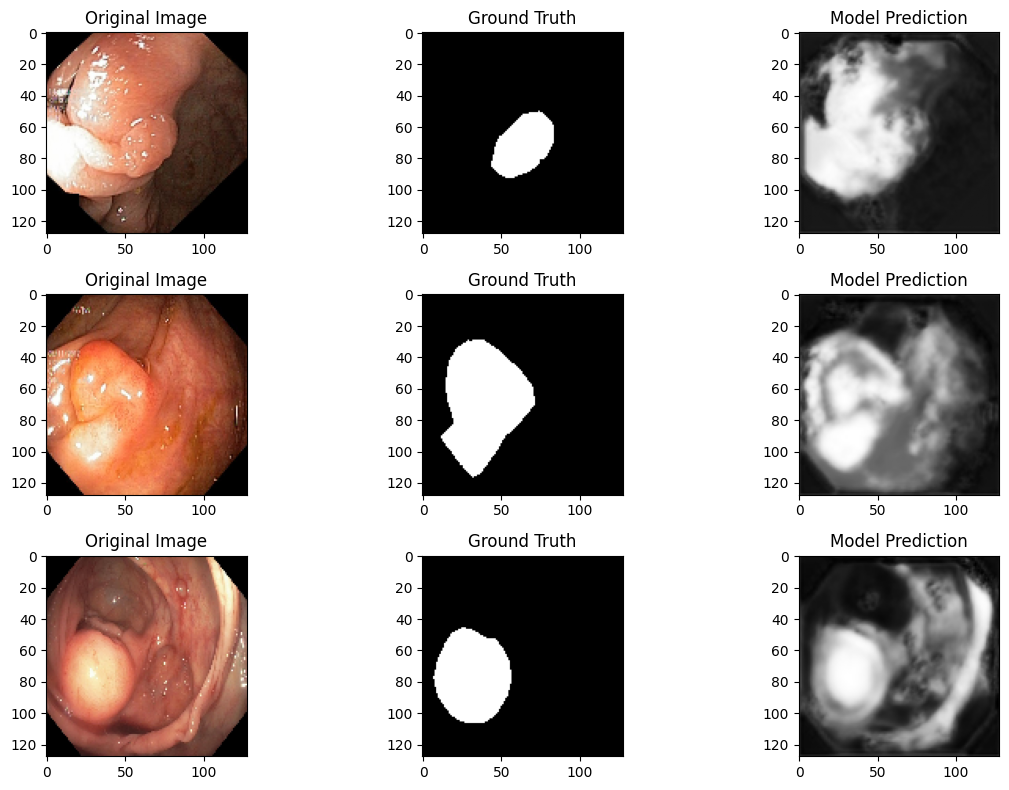

In [ ]:
import matplotlib.pyplot as plt

def visualize_results(model, loader, num_samples=3):
    model.eval()
    imgs, masks = next(iter(loader))
    imgs, masks = imgs[:num_samples].to(device), masks[:num_samples].to(device)
    preds = model(imgs)

    plt.figure(figsize=(12, 8))
    for i in range(num_samples):
        plt.subplot(num_samples, 3, i*3 + 1)
        plt.imshow(imgs[i].permute(1,2,0).cpu())
        plt.title("Original Image")

        plt.subplot(num_samples, 3, i*3 + 2)
        plt.imshow(masks[i][0].cpu(), cmap='gray')
        plt.title("Ground Truth")

        plt.subplot(num_samples, 3, i*3 + 3)
        plt.imshow(preds[i][0].detach().cpu(), cmap='gray')
        plt.title("Model Prediction")
    plt.tight_layout()
    plt.show()

print("Visualizing Pruned Model Predictions:")
visualize_results(model_pruned, test_loader)